## The irreducible mass of black holes.

For a BH of mass $M$ spin $\chi\in [0,1]$, the irreducible mass is 

$$\begin{equation}
    M_{\rm irr} = %\sqrt{\frac{M^2+\sqrt{M^4-S^2}}{2}} = 
     M \sqrt{\frac{1+\sqrt{1-\chi^2}}{2}}
\end{equation}$$

For convenience, let us define 

$$f(\chi) = \sqrt{\frac{1+\sqrt{1-\chi^2}}{2}} = M_{\rm irr} / M$$

Suppose you have repeated measurments of $M$ and $\chi$. This is just because we're still frequentists for now. When we will put our Bayesian hat on, these distributions will be the *posterior samples* from a single measurement.

Let's assume that

- the spin $\chi$ is uniformly distributed between 0 and 1.
- the mass $M$ is normally distributed with mean $\mu$ and standard deviation $\sigma$.
- (masses and spins are uncorrelated)

These are simplistic assumption that, however, are not too far from what we are now measuring with gravitational-wave detectors. It's a toy model, but not a totally unreasonable one.

**Tasks**:

1. Start with a value of $\sigma=0.02$. Note that $\mu$ is a scale and not a parameter: you can normalize all quantities with a dimension of mass by $\mu$. Just set $\mu=1$ in your code and remember that all masses in the problem are measured in units of $\mu$. 

2. Plot the resulting pdf of $M_{\rm irr}$. First try an histogram with one the rules of thumb we've seen above.

*Hint (for point 2)*: You don't know the functional form of the pdf of $M_{\rm irr}$... but you don't need it if you just want to generate samples! That's the nice thing about numerics!

3. Using the same samples, plot the distribution of $M_{\rm irr}$ using a KDE.

4. Compute the KS distance between ${M_{\rm irr}}/\mu$ and ${f}$ as a function of $\sigma$. Discuss the limits at large and small values of $\sigma$. 

5. Compute the KS distance between ${M_{\rm irr}}$ and $M$ as a function of $\sigma$. Discuss the limits at large and small values of $\sigma$.

*Hint (for points 4 and 5)*. This is a KS test between two sets for samples, `scipy.stats.ks_2samp`.

You should find that (i) $M_{\rm irr}$ is distributed like $f$ if ${\sigma}\ll \mu$ and (ii) $M_{\rm irr}$ is distributed like $M$ if  $\sigma\gg \mu$.

In [1]:
import numpy as np
from matplotlib import pyplot as plt
from scipy.stats import norm, uniform
from scipy import stats
from sklearn.neighbors import KernelDensity
import astropy.visualization.hist


Let's have a look at our distribution of $M_{irr}$:

In [2]:
N = 10000
chi = uniform.rvs(0, 1, N)
f = np.sqrt((1+np.sqrt(1-chi**2))/2)

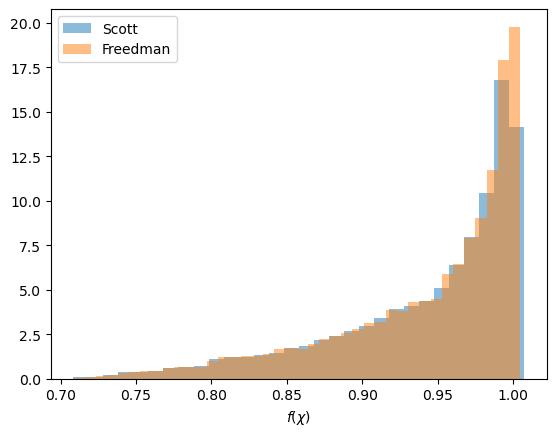

In [3]:
astropy.visualization.hist(f, bins='scott', density=True, alpha=0.5, label='Scott')
astropy.visualization.hist(f, bins='freedman', density=True, alpha=0.5, label='Freedman')
plt.xlabel(r'$f(\chi)$')
plt.legend()

Let's now sample the mass distribution and plot the pdf of $M_{irr}$:

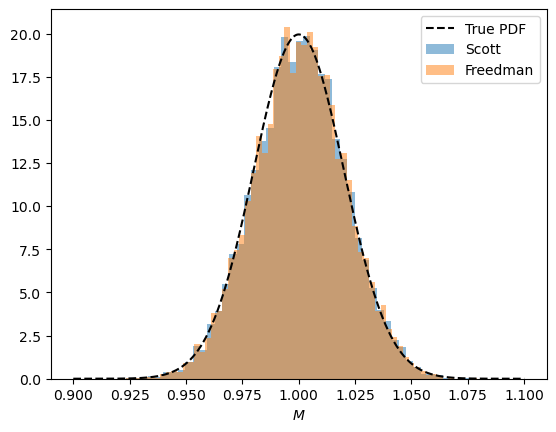

In [4]:
mu = 1
sigma = 0.02

mass = norm.rvs(mu, sigma, N)
x_grid = np.linspace(mu-5*sigma, mu+5*sigma, N)
true_pdf =  norm.pdf(x_grid, mu, sigma)

plt.plot(x_grid, true_pdf, '--k', label='True PDF')
astropy.visualization.hist(mass, bins='scott', density=True, alpha=0.5, label='Scott')
astropy.visualization.hist(mass, bins='freedman', density=True, alpha=0.5, label='Freedman')
plt.xlabel(r'$M$')
plt.legend()

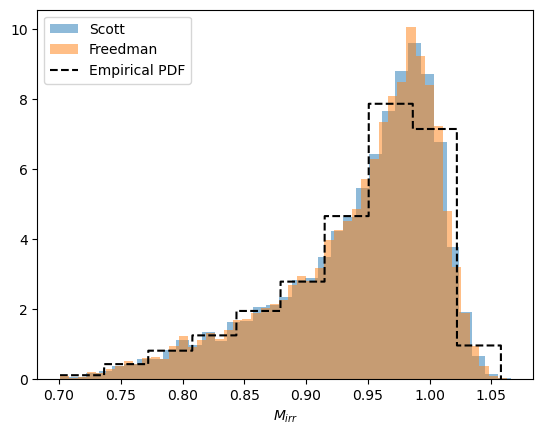

In [5]:
M_irr = f*mass

M_irr_hist = np.histogram(M_irr, density=True)
M_irr_pdf = stats.rv_histogram(M_irr_hist)

x_grid = np.linspace(M_irr.min(), M_irr.max(), N)

astropy.visualization.hist(M_irr, bins='scott', density=True, alpha=0.5, label='Scott')
astropy.visualization.hist(M_irr, bins='freedman', density=True, alpha=0.5, label='Freedman')
plt.plot(x_grid, M_irr_pdf.pdf(x_grid), '--k', label='Empirical PDF')
plt.xlabel(r'$M_{irr}$')
plt.legend()

Let's now use a KDE:

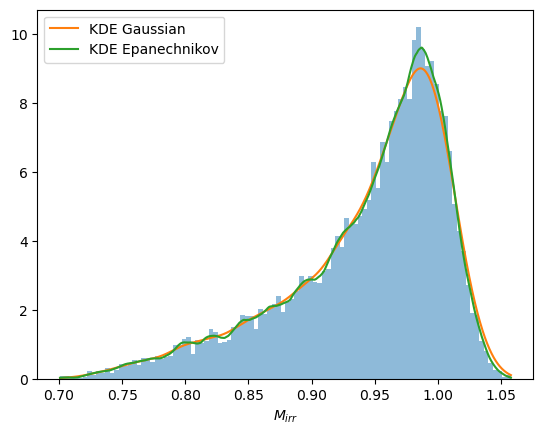

In [6]:
def kde (data, bandwidth, kernel):
    kde_skl = KernelDensity(bandwidth=bandwidth, kernel=kernel)
    kde_skl.fit(data[:, np.newaxis])
    log_pdf = kde_skl.score_samples((x_grid[:, np.newaxis]))
    return np.exp(log_pdf)

M_irr_kde_gauss = kde(M_irr, bandwidth=0.01, kernel='gaussian')
M_irr_kde_epan = kde(M_irr, bandwidth=0.01, kernel='epanechnikov')
plt.plot(x_grid, M_irr_kde_gauss, label='KDE Gaussian' , color='C1')
plt.plot(x_grid, M_irr_kde_epan, label='KDE Epanechnikov', color='C2')
plt.hist(M_irr, bins=100, density=True, alpha=0.5, color='C0')
plt.xlabel(r'$M_{irr}$')
plt.legend()

Let's now compute the KS distance between ${M_{\rm irr}}/\mu$ and ${f}$ and between ${M_{\rm irr}}$ and $M$ as a function of $\sigma$. Let's start by looking at how ${M_{\rm irr}}$ is distributedas a function of $\sigma$:

In [7]:
def M_irr(sigma):
    mass = np.random.normal(mu, sigma, N)
    chi = np.random.uniform(0, 1, N)
    f = np.sqrt((1+np.sqrt(1-chi**2))/2)
    M_irr = mass*f
    return M_irr

small_M_irr = M_irr(sigma=0.001)
big_M_irr = M_irr(sigma=10)

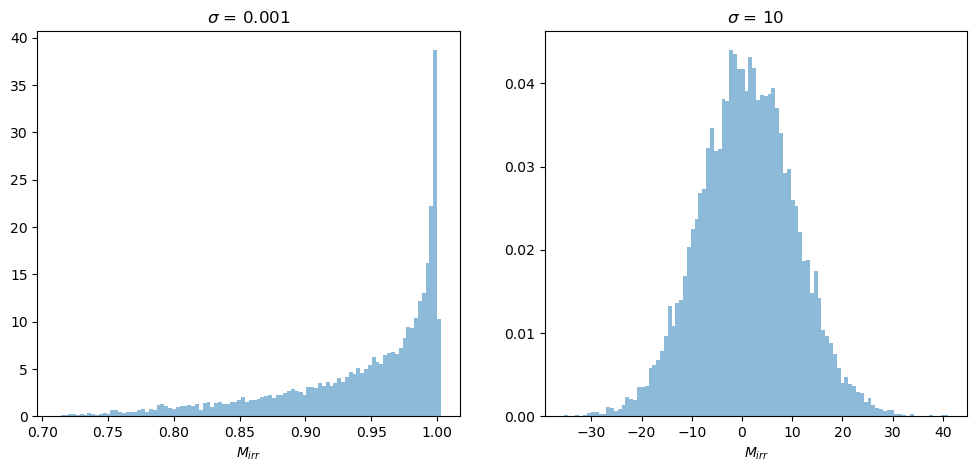

In [8]:
fig, ax = plt.subplots(1, 2, figsize=(12, 5))

ax[0].set_title(r'$\sigma$ = 0.001')
ax[0].hist(small_M_irr, bins = 100, density = True, alpha=0.5)
ax[0].set_xlabel(r'$M_{irr}$')
ax[1].set_title(r'$\sigma$ = 10')
ax[1].hist(big_M_irr, bins = 100, density = True, alpha=0.5)
ax[1].set_xlabel(r'$M_{irr}$')
plt.show()

As expected, $M_{\rm irr}$ is distributed like $f$ if ${\sigma}\ll \mu$ and $M_{\rm irr}$ is distributed like $M$ if  $\sigma\gg \mu$.

The KS distance is:

In [9]:
N_sigma = 10
sigmas = np.linspace(0.001, 15, N_sigma)
KS_f = []
KS_m = []

chi = np.random.uniform(0, 1, N)
f = np.sqrt((1+np.sqrt(1-chi**2))/2)

for sigma in sigmas:
    mass = np.random.normal(mu, sigma, N)
    KS_m.append(stats.ks_2samp(mass, mass*f))
    KS_f.append(stats.ks_2samp(f, mass*f))

KS_f= np.array(KS_f)
KS_m = np.array(KS_m)

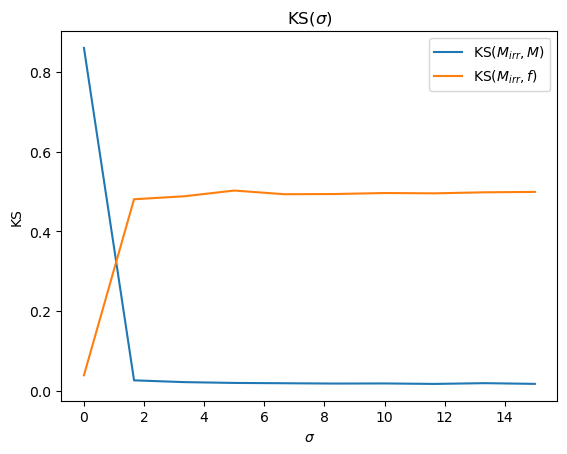

In [10]:
plt.plot(sigmas, KS_m[:,0], label = r'KS($M_{irr}, M$)')
plt.plot(sigmas, KS_f[:,0], label = r'KS($M_{irr}, f$)')
plt.xlabel(r'$\sigma$')
plt.ylabel('KS')
plt.title(r'KS($\sigma$)')
plt.legend()

For small KS values, the distributions of the two samples are similar. Indeed, as we saw before, for small $\sigma$, $M_{\rm irr}$ is distributed like $f$, while for large $\sigma$, it is distributed like $M$!